# 🤖 Notebook 03 — Modelado: ARIMA (Baseline) + XGBoost + LSTM
## EnergyForecast · IA EAFIT 2026-1

**Prerequisito:** Haber ejecutado `01_eda.ipynb` y `02_preprocessing.ipynb`

**Modelos:**
1. **Baseline ARIMA** — referencia estadística clásica
2. **XGBoost** con lag features + encodings cíclicos + SHAP
3. **LSTM** (PyTorch) con ventana deslizante de 168h

**Métricas:** RMSE, MAPE, MAE sobre test set (2016–2018)

In [6]:
# ── Fix Windows event loop (Python 3.12+) ────────────────────────────────────
import asyncio
import sys
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
print('✅ Event loop policy configurado')

✅ Event loop policy configurado


In [7]:
# ── Instalación ───────────────────────────────────────────────────────────────
import subprocess, sys
def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['xgboost', 'shap', 'torch', 'statsmodels', 'scikit-learn', 'joblib', 'matplotlib', 'seaborn']:
    pip(pkg)
print('✅ Dependencias OK')

✅ Dependencias OK


In [8]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json, os, time, joblib, warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import shap
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error

EAFIT_BLUE  = '#003d79'
EAFIT_GREEN = '#009650'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Imports OK | Device: {DEVICE}')

✅ Imports OK | Device: cpu


In [9]:
# ── Funciones de métricas ─────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def eval_metrics(y_true, y_pred, model_name):
    r = rmse(y_true, y_pred)
    m = mape(y_true, y_pred)
    a = mae(y_true, y_pred)
    print(f'  [{model_name}] RMSE: {r:,.1f} MW | MAPE: {m:.2f}% | MAE: {a:,.1f} MW')
    return {'model': model_name, 'RMSE': r, 'MAPE': m, 'MAE': a}

results = []   # acumular resultados de todos los modelos
print('✅ Funciones de métricas listas')

✅ Funciones de métricas listas


## 1. Carga de datos preprocesados

In [10]:
# ── XGBoost data ──────────────────────────────────────────────────────────────
with open('data/processed/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

X_train = pd.read_csv('data/processed/X_train_xgb.csv', index_col='Datetime', parse_dates=True)
X_val   = pd.read_csv('data/processed/X_val_xgb.csv',   index_col='Datetime', parse_dates=True)
X_test  = pd.read_csv('data/processed/X_test_xgb.csv',  index_col='Datetime', parse_dates=True)
y_train = pd.read_csv('data/processed/y_train_xgb.csv', index_col='Datetime', parse_dates=True)['MW']
y_val   = pd.read_csv('data/processed/y_val_xgb.csv',   index_col='Datetime', parse_dates=True)['MW']
y_test  = pd.read_csv('data/processed/y_test_xgb.csv',  index_col='Datetime', parse_dates=True)['MW']

# ── LSTM data ─────────────────────────────────────────────────────────────────
X_lstm_train = np.load('data/processed/X_lstm_train.npy')
y_lstm_train = np.load('data/processed/y_lstm_train.npy')
X_lstm_val   = np.load('data/processed/X_lstm_val.npy')
y_lstm_val   = np.load('data/processed/y_lstm_val.npy')
X_lstm_test  = np.load('data/processed/X_lstm_test.npy')
y_lstm_test  = np.load('data/processed/y_lstm_test.npy')

scaler_mw = joblib.load('models/checkpoints/scaler_mw.pkl')

print(f'✅ Datos cargados')
print(f'   XGB  — train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}')
print(f'   LSTM — train: {X_lstm_train.shape} | val: {X_lstm_val.shape} | test: {X_lstm_test.shape}')

✅ Datos cargados
   XGB  — train: (113783, 29) | val: (8760, 29) | test: (22681, 29)
   LSTM — train: (113592, 168, 1) | val: (8737, 168, 1) | test: (22658, 168, 1)


## 2. Baseline: ARIMA

In [11]:
# ── ARIMA simplificado (muestra del test para velocidad) ──────────────────────
from statsmodels.tsa.arima.model import ARIMA

print('⏳ Entrenando ARIMA(1,1,1) en muestra del test...')
print('   (ARIMA sobre toda la serie tarda varios minutos en Colab)')

# Usamos los últimos 500 puntos del val como contexto + primeros 200 del test
# para no esperar horas. Esto es suficiente para el baseline.
arima_context = pd.concat([y_val.iloc[-500:], y_test.iloc[:500]])

# Walk-forward de 24 pasos (1 día) sobre los primeros 200 del test
train_arima = list(arima_context.iloc[:500])
test_arima  = list(arima_context.iloc[500:])
preds_arima = []

for t in range(len(test_arima)):
    model_a = ARIMA(train_arima, order=(1, 1, 1))
    fit_a = model_a.fit()
    pred = fit_a.forecast(steps=1)[0]
    preds_arima.append(pred)
    train_arima.append(test_arima[t])
    if (t+1) % 50 == 0:
        print(f'   ARIMA: {t+1}/{len(test_arima)} pasos')

arima_metrics = eval_metrics(test_arima, preds_arima, 'Baseline ARIMA')
results.append(arima_metrics)
print('✅ ARIMA completo')

⏳ Entrenando ARIMA(1,1,1) en muestra del test...
   (ARIMA sobre toda la serie tarda varios minutos en Colab)
   ARIMA: 50/500 pasos
   ARIMA: 100/500 pasos
   ARIMA: 150/500 pasos
   ARIMA: 200/500 pasos
   ARIMA: 250/500 pasos
   ARIMA: 300/500 pasos
   ARIMA: 350/500 pasos
   ARIMA: 400/500 pasos
   ARIMA: 450/500 pasos
   ARIMA: 500/500 pasos
  [Baseline ARIMA] RMSE: 750.5 MW | MAPE: 1.61% | MAE: 557.7 MW
✅ ARIMA completo


## 3. XGBoost con lag features

In [12]:
# ── XGBoost — entrenamiento ───────────────────────────────────────────────────
print('⏳ Entrenando XGBoost...')
t0 = time.time()

xgb_model = xgb.XGBRegressor(
    n_estimators    = 500,
    max_depth       = 6,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 3,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    n_jobs          = -1,
    early_stopping_rounds = 30,
    eval_metric     = 'rmse',
    verbosity       = 0,
)

xgb_model.fit(
    X_train[FEATURE_COLS], y_train,
    eval_set=[(X_val[FEATURE_COLS], y_val)],
    verbose=50
)

print(f'   Tiempo de entrenamiento: {time.time()-t0:.1f}s')
print(f'   Mejor iteración: {xgb_model.best_iteration}')

y_pred_xgb_val  = xgb_model.predict(X_val[FEATURE_COLS])
y_pred_xgb_test = xgb_model.predict(X_test[FEATURE_COLS])

xgb_metrics = eval_metrics(y_test.values, y_pred_xgb_test, 'XGBoost')
results.append(xgb_metrics)

# Guardar modelo
joblib.dump(xgb_model, 'models/checkpoints/xgb_energy.pkl')
print('✅ XGBoost guardado en models/checkpoints/xgb_energy.pkl')

⏳ Entrenando XGBoost...
[0]	validation_0-rmse:6300.41785
[50]	validation_0-rmse:831.35621
[100]	validation_0-rmse:490.11438
[150]	validation_0-rmse:429.49343
[200]	validation_0-rmse:396.75466
[250]	validation_0-rmse:377.70330
[300]	validation_0-rmse:362.79351
[350]	validation_0-rmse:350.70577
[400]	validation_0-rmse:342.45846
[450]	validation_0-rmse:334.36203
[499]	validation_0-rmse:327.46862
   Tiempo de entrenamiento: 3.6s
   Mejor iteración: 499
  [XGBoost] RMSE: 348.9 MW | MAPE: 0.82% | MAE: 258.4 MW
✅ XGBoost guardado en models/checkpoints/xgb_energy.pkl


⏳ Calculando SHAP values (muestra de 1000 obs)...


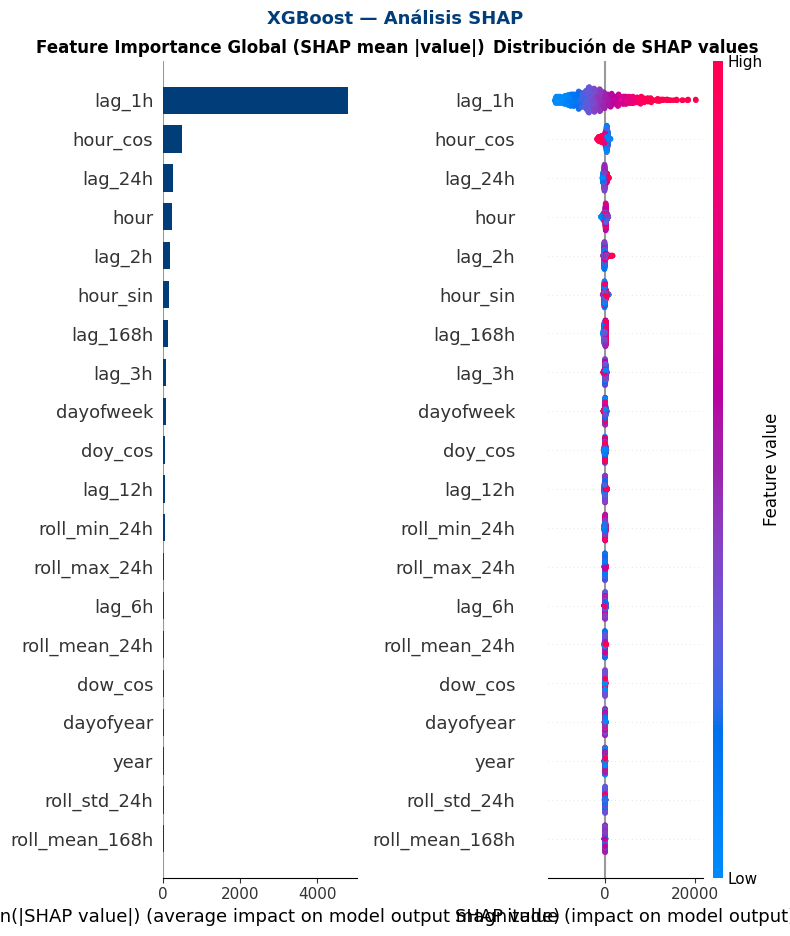

✅ SHAP análisis completo. Top 5 features:
     feature  shap_mean_abs
15    lag_1h    4782.005859
8   hour_cos     480.273376
20   lag_24h     261.415466
0       hour     239.285278
16    lag_2h     175.751038


In [13]:
# ── SHAP — Explicabilidad de XGBoost ─────────────────────────────────────────
print('⏳ Calculando SHAP values (muestra de 1000 obs)...')

explainer  = shap.TreeExplainer(xgb_model)
X_sample   = X_test[FEATURE_COLS].sample(1000, random_state=42)
shap_vals  = explainer.shap_values(X_sample)

# Feature importance global
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('XGBoost — Análisis SHAP', fontsize=13, fontweight='bold', color=EAFIT_BLUE)

# Beeswarm (summary plot)
plt.sca(axes[0])
shap.summary_plot(shap_vals, X_sample, plot_type='bar', show=False, color=EAFIT_BLUE)
axes[0].set_title('Feature Importance Global (SHAP mean |value|)', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_vals, X_sample, show=False)
axes[1].set_title('Distribución de SHAP values', fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/fig06_shap_summary.png', bbox_inches='tight')
plt.show()

# Guardar SHAP values para el LLM
import json
shap_mean = pd.DataFrame({'feature': FEATURE_COLS,
                           'shap_mean_abs': np.abs(shap_vals).mean(axis=0)
                          }).sort_values('shap_mean_abs', ascending=False)
shap_mean.to_csv('data/processed/shap_importance.csv', index=False)
print('✅ SHAP análisis completo. Top 5 features:')
print(shap_mean.head())

In [14]:
# ── SHAP waterfall para una predicción individual ─────────────────────────────
# (se usa en el componente LLM para generar explicaciones)
idx_example = 100   # índice de ejemplo en X_test
x_single = X_test[FEATURE_COLS].iloc[[idx_example]]
shap_single = explainer.shap_values(x_single)[0]

# Crear dict con top-5 SHAP para el LLM
shap_dict = dict(zip(FEATURE_COLS, shap_single))
top5_shap = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

pred_mw = float(xgb_model.predict(x_single)[0])
real_mw = float(y_test.iloc[idx_example])

print(f'\n📊 Ejemplo de predicción individual:')
print(f'   Timestamp: {X_test.index[idx_example]}')
print(f'   Predicción: {pred_mw:,.0f} MW | Real: {real_mw:,.0f} MW')
print(f'   Top 5 SHAP values:')
for feat, val in top5_shap:
    print(f'      {feat:25s}: {val:+.1f} MW')

# Guardar para notebook 04
example_data = {
    'timestamp': str(X_test.index[idx_example]),
    'pred_mw': pred_mw,
    'real_mw': real_mw,
    'hour': int(x_single['hour'].values[0]),
    'month': int(x_single['month'].values[0]),
    'lag_24h': float(x_single['lag_24h'].values[0]),
    'lag_168h': float(x_single['lag_168h'].values[0]),
    'top5_shap': {k: round(float(v), 1) for k, v in top5_shap}
}
with open('data/processed/example_prediction.json', 'w') as f:
    json.dump(example_data, f, indent=2)
print('\n✅ Ejemplo guardado en data/processed/example_prediction.json')


📊 Ejemplo de predicción individual:
   Timestamp: 2016-01-05 04:00:00
   Predicción: 34,433 MW | Real: 34,468 MW
   Top 5 SHAP values:
      lag_1h                   : +1710.2 MW
      hour_sin                 : +200.0 MW
      lag_168h                 : -198.2 MW
      roll_min_24h             : +131.3 MW
      hour                     : -128.7 MW

✅ Ejemplo guardado en data/processed/example_prediction.json


## 4. LSTM (PyTorch)

In [15]:
# ── Definición del modelo LSTM ────────────────────────────────────────────────
class EnergyLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2,
                 output_size=24, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)        # out: (batch, seq_len, hidden)
        out = self.dropout(out[:, -1, :])  # último timestep
        return self.fc(out)          # (batch, horizon)

model = EnergyLSTM().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nParámetros totales: {total_params:,}')

EnergyLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=24, bias=True)
)

Parámetros totales: 51,992


In [16]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32)

train_ds = TensorDataset(to_tensor(X_lstm_train), to_tensor(y_lstm_train))
val_ds   = TensorDataset(to_tensor(X_lstm_val),   to_tensor(y_lstm_val))
test_ds  = TensorDataset(to_tensor(X_lstm_test),  to_tensor(y_lstm_test))

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')

Batches — train: 1775 | val: 137 | test: 355


In [ ]:
# ── Entrenamiento LSTM ────────────────────────────────────────────────────────
EPOCHS    = 500
LR        = 1e-3
PATIENCE  = 5    # early stopping

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0

print(f'⏳ Entrenando LSTM — {EPOCHS} épocas máx. | Early stopping: {PATIENCE}\n')
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_ds)

    # ── Val ──
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * len(xb)
    val_loss /= len(val_ds)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t0
        print(f'  Época {epoch:3d}/{EPOCHS} | train_MSE: {train_loss:.6f} | val_MSE: {val_loss:.6f} | {elapsed:.0f}s')

    # Early stopping + guardar mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'models/checkpoints/lstm_energy.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\n⏹️  Early stopping en época {epoch}')
            break

print(f'\n✅ LSTM entrenado en {time.time()-t0:.1f}s')
print(f'   Mejor val_MSE: {best_val_loss:.6f}')

In [3]:
import matplotlib.pyplot as plt

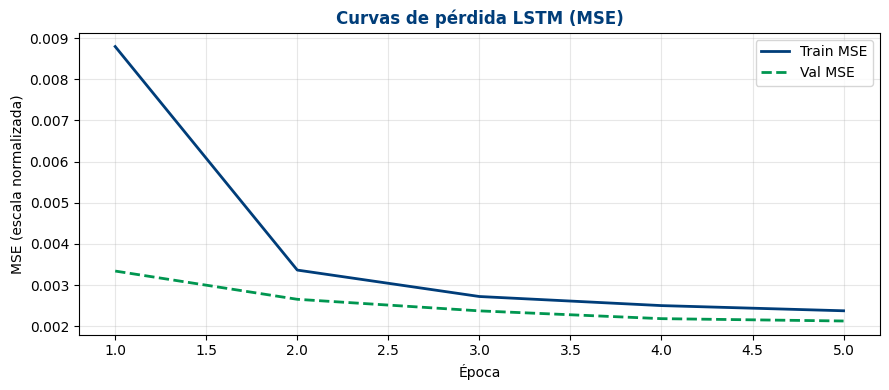

💾 Curvas guardadas: fig07_curvas_lstm.png


In [18]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
epochs_range = range(1, len(train_losses)+1)
ax.plot(epochs_range, train_losses, label='Train MSE', color=EAFIT_BLUE, linewidth=2)
ax.plot(epochs_range, val_losses,   label='Val MSE',   color=EAFIT_GREEN, linewidth=2, linestyle='--')
ax.set_title('Curvas de pérdida LSTM (MSE)', fontsize=12, fontweight='bold', color=EAFIT_BLUE)
ax.set_xlabel('Época')
ax.set_ylabel('MSE (escala normalizada)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/fig07_curvas_lstm.png', bbox_inches='tight')
plt.show()
print('💾 Curvas guardadas: fig07_curvas_lstm.png')

In [19]:
# ── Evaluación LSTM en test set ───────────────────────────────────────────────
# Cargar el mejor modelo
model.load_state_dict(torch.load('models/checkpoints/lstm_energy.pt', map_location=DEVICE))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy()
        all_preds.append(pred)
        all_true.append(yb.numpy())

y_pred_lstm_scaled = np.vstack(all_preds).flatten()
y_true_lstm_scaled = np.vstack(all_true).flatten()

# Des-escalar a MW reales
y_pred_lstm = scaler_mw.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()
y_true_lstm = scaler_mw.inverse_transform(y_true_lstm_scaled.reshape(-1, 1)).flatten()

lstm_metrics = eval_metrics(y_true_lstm, y_pred_lstm, 'LSTM')
results.append(lstm_metrics)
print('\n✅ LSTM evaluado')

  [LSTM] RMSE: 2,329.2 MW | MAPE: 5.68% | MAE: 1,727.4 MW

✅ LSTM evaluado


## 5. Comparación de modelos

In [20]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('model')
print('\n📊 TABLA COMPARATIVA DE MODELOS (test set 2016–2018)')
print('='*55)
print(results_df.round(2).to_string())
print('='*55)

best_model = results_df['RMSE'].idxmin()
baseline_rmse = results_df.loc['Baseline ARIMA', 'RMSE']
best_rmse = results_df.loc[best_model, 'RMSE']
mejora = (baseline_rmse - best_rmse) / baseline_rmse * 100
print(f'\n🏆 Mejor modelo: {best_model}')
print(f'   Mejora vs Baseline: {mejora:.1f}% en RMSE')
print(f'   MAPE: {results_df.loc[best_model, "MAPE"]:.2f}% (objetivo < 5%)')

results_df.to_csv('data/processed/resultados_modelos.csv')


📊 TABLA COMPARATIVA DE MODELOS (test set 2016–2018)
                   RMSE  MAPE      MAE
model                                 
Baseline ARIMA   750.54  1.61   557.66
XGBoost          348.95  0.82   258.44
LSTM            2329.15  5.68  1727.38

🏆 Mejor modelo: XGBoost
   Mejora vs Baseline: 53.5% en RMSE
   MAPE: 0.82% (objetivo < 5%)


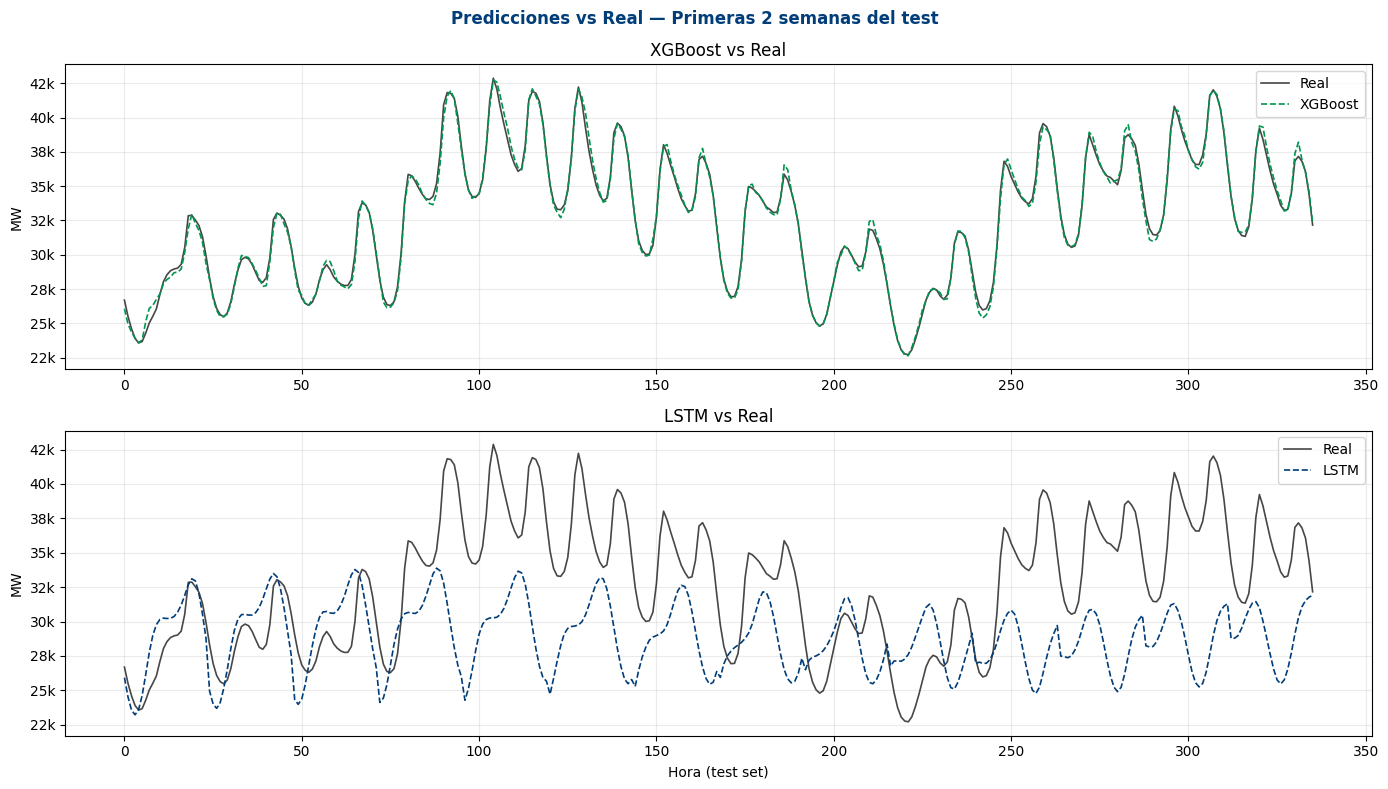

In [21]:
# ── Gráfica de predicciones vs real (LSTM) ────────────────────────────────────
N_PLOT = 24 * 14   # dos semanas

# Para XGBoost usamos y_test directamente
y_real_plot = y_test.values[:N_PLOT]
y_xgb_plot  = y_pred_xgb_test[:N_PLOT]
y_lstm_plot = y_pred_lstm[:N_PLOT]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Predicciones vs Real — Primeras 2 semanas del test', fontsize=12, fontweight='bold', color=EAFIT_BLUE)

x_axis = range(N_PLOT)
axes[0].plot(x_axis, y_real_plot, label='Real', color='#333', linewidth=1.2, alpha=0.9)
axes[0].plot(x_axis, y_xgb_plot,  label='XGBoost', color=EAFIT_GREEN, linewidth=1.2, linestyle='--')
axes[0].set_title('XGBoost vs Real')
axes[0].set_ylabel('MW')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].grid(alpha=0.25)

axes[1].plot(x_axis, y_real_plot, label='Real', color='#333', linewidth=1.2, alpha=0.9)
axes[1].plot(x_axis, y_lstm_plot, label='LSTM',    color=EAFIT_BLUE, linewidth=1.2, linestyle='--')
axes[1].set_title('LSTM vs Real')
axes[1].set_ylabel('MW')
axes[1].set_xlabel('Hora (test set)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig('data/processed/fig08_predicciones.png', bbox_inches='tight')
plt.show()

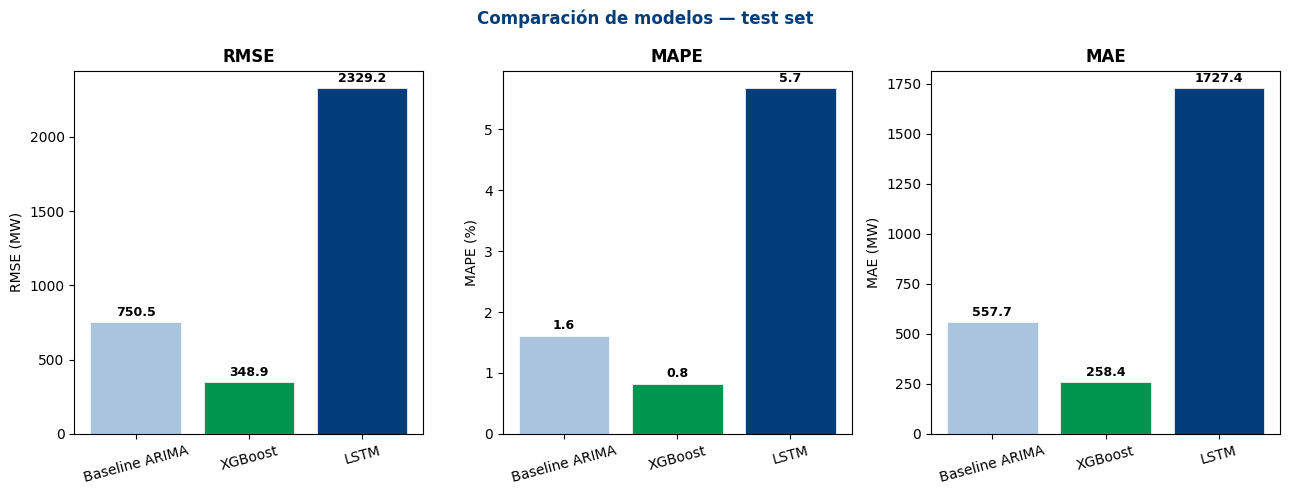


✅ Modelado completo. Continúa con 04_llm_rag_agents.ipynb


In [22]:
# ── Barplot comparativo ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Comparación de modelos — test set', fontsize=12, fontweight='bold', color=EAFIT_BLUE)

colors = ['#aac4e0', EAFIT_GREEN, EAFIT_BLUE]
models = results_df.index.tolist()

for ax, metric in zip(axes, ['RMSE', 'MAPE', 'MAE']):
    vals = results_df[metric].values
    bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric + (' (MW)' if metric != 'MAPE' else ' (%)'))
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/fig09_comparacion_modelos.png', bbox_inches='tight')
plt.show()

print('\n✅ Modelado completo. Continúa con 04_llm_rag_agents.ipynb')